---
date: "2026-07-18"
date-modified: last-modified
format:
  html:
    toc: true
---

# The Beta Distribution and Bayes' Billiards

While the [Uniform distribution](uniform-distribution.ipynb) $\text{Unif}(0, 1)$ describes completely flat, uninformative randomness over the unit interval, many real-world quantities restricted to $(0, 1)$—such as probabilities, proportions, percentages, and rates—exhibit strong skewness, central clustering, or boundary concentration. To model these bounded continuous phenomena, we introduce the **Beta distribution**: a highly flexible family of continuous distributions that serves as the direct generalization of the Uniform distribution on $(0, 1)$ and acts as the fundamental [conjugate prior]() for binomial proportions in Bayesian statistics.


## 1\. Definition and Shape Flexibility

The Beta distribution is parameterized by two positive shape parameters, $a > 0$ and $b > 0$, which govern the relative weights assigned to the left boundary ($0$) versus the right boundary ($1$).

::: {#def-beta-distribution}
## The Beta Distribution
A [continuous random variable](continuous-rv.ipynb) $X$ is said to follow a **Beta distribution** with parameters $a > 0$ and $b > 0$, denoted $X \sim \text{Beta}(a, b)$, if its probability density function (PDF) is given by:

$$
f(x) = \frac{1}{B(a, b)} x^{a - 1} (1 - x)^{b - 1}, \quad 0 < x < 1
$$

and $f(x) = 0$ for $x \le 0$ or $x \ge 1$. Here, $c = \frac{1}{B(a, b)}$ is the normalizing constant required to ensure the density integrates to $1$ over $(0, 1)$. The function $B(a, b)$ is the **Beta function**, defined via the integral:

$$
B(a, b) = \int_0^1 x^{a - 1} (1 - x)^{b - 1} \, dx
$$

For any positive real numbers $a, b > 0$, the Beta function is intimately connected to the [Gamma function]() $\Gamma(z)$ via the identity:

$$
B(a, b) = \frac{\Gamma(a)\Gamma(b)}{\Gamma(a + b)}
$$
:::

::: {.callout-warning}
## Terminology Trap: Beta Function vs. Beta Distribution
Do not confuse the **Beta function** $B(a, b)$ with the **Beta distribution** $\text{Beta}(a, b)$!
The Beta function $B(a, b)$ is a deterministic **scalar normalization constant** (a definite integral equal to $\frac{\Gamma(a)\Gamma(b)}{\Gamma(a+b)}$). The Beta distribution $\text{Beta}(a, b)$ is the **probability distribution** of a random variable whose density curve is proportional to $x^{a-1}(1-x)^{b-1}$.
:::

### 1.1\. Shape Flexibility and Classic Archetypes

Because the exponents $(a - 1)$ and $(b - 1)$ can be positive, zero, or negative, varying $a$ and $b$ allows the Beta density to adopt an extraordinary variety of shapes on $(0, 1)$:

1. **Flat / Uniform Case ($a = 1, b = 1$):**
   When both parameters equal $1$, the exponents vanish ($x^0(1-x)^0 = 1$), and $B(1, 1) = 1$. The density reduces to the standard flat Uniform distribution: $\text{Beta}(1, 1) \equiv \text{Unif}(0, 1)$.
2. **Linear Increasing Triangle ($a = 2, b = 1$):**
   The density simplifies to $f(x) = 2x$ on $(0, 1)$, forming a right triangle rising steadily toward $x = 1$. Conversely, $\text{Beta}(1, 2)$ yields a decreasing linear slope $f(x) = 2(1-x)$.
3. **U-Shaped / Boundary Concentrated Case ($a = \frac{1}{2}, b = \frac{1}{2}$):**
   When $a, b < 1$, the density $f(x) \propto x^{-1/2}(1-x)^{-1/2} = \frac{1}{\sqrt{x(1-x)}}$ diverges to infinity at both boundaries $x \to 0^+$ and $x \to 1^-$, forming a U-shaped curve known as the **Arcsine distribution**.
4. **Unimodal / Bell-Shaped ($a > 1, b > 1$):**
   When both shape parameters strictly exceed $1$, the density is unimodal with a unique interior mode at $x = \frac{a - 1}{a + b - 2}$. If $a = b > 1$, the density is perfectly symmetric around $x = 0.5$ (e.g., $\text{Beta}(2, 2)$ is a parabola forming a soft dome). If $a > b$, the density is left-skewed (clustered near $1$); if $a < b$, it is right-skewed (clustered near $0$).

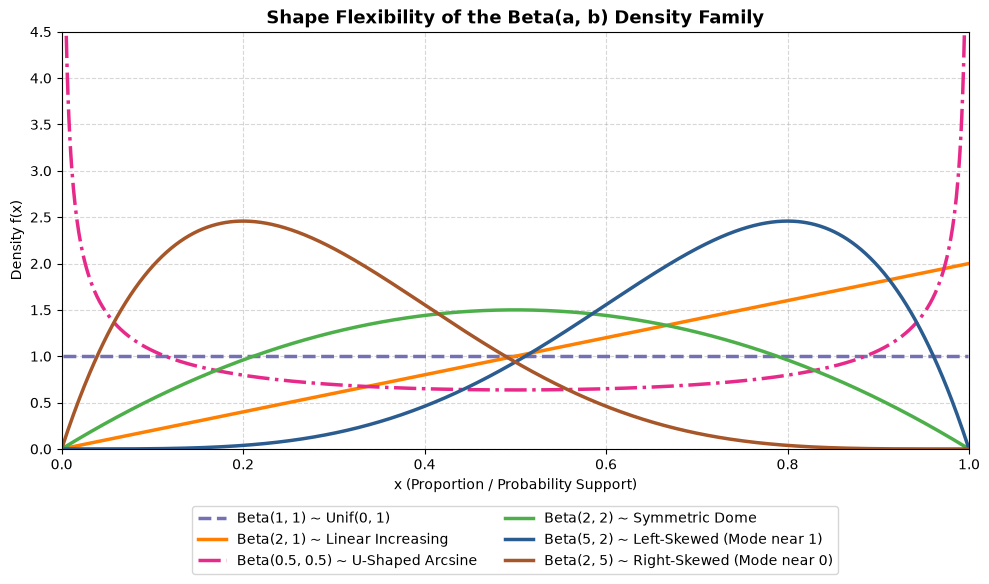

In [1]:
#| label: fig-beta-flexibility
#| fig-cap: "The remarkable shape flexibility of the Beta(a, b) family on the unit interval. Varying the shape parameters transforms the density from flat Uniform (1, 1), to linear triangle (2, 1), U-shaped Arcsine (0.5, 0.5), symmetric dome (2, 2), and skewed unimodal curves (5, 2 and 2, 5)."

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

x = np.linspace(0.001, 0.999, 1000)

params = [
    (1, 1, 'Beta(1, 1) ~ Unif(0, 1)', '#7570b3', '--'),
    (2, 1, 'Beta(2, 1) ~ Linear Increasing', '#ff7f00', '-'),
    (0.5, 0.5, 'Beta(0.5, 0.5) ~ U-Shaped Arcsine', '#e7298a', '-.'),
    (2, 2, 'Beta(2, 2) ~ Symmetric Dome', '#4daf4a', '-'),
    (5, 2, 'Beta(5, 2) ~ Left-Skewed (Mode near 1)', '#2b5c8f', '-'),
    (2, 5, 'Beta(2, 5) ~ Right-Skewed (Mode near 0)', '#a65628', '-')
]

plt.figure(figsize=(10, 6))

for a_val, b_val, label, color, style in params:
    y = beta.pdf(x, a_val, b_val)
    plt.plot(x, y, label=label, color=color, linestyle=style, linewidth=2.5)

plt.title('Shape Flexibility of the Beta(a, b) Density Family', fontsize=13, fontweight='bold')
plt.xlabel('x (Proportion / Probability Support)')
plt.ylabel('Density f(x)')
plt.xlim(0, 1)
plt.ylim(0, 4.5)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, fontsize=10)
plt.tight_layout()
plt.show()


## 2\. Bayesian Inference and Beta-Binomial Conjugacy

In Bayesian statistics, when estimating an unknown probability parameter $p \in (0, 1)$ (such as the true success probability of a coin or a medical treatment), we treat $p$ as a random variable with a **prior distribution** reflecting our initial beliefs before observing data. When our experimental data consists of counts of successes and failures from independent trials—modeled by a [Binomial distribution](bernoulli-and-binomial-distributions.ipynb)—the Beta distribution serves as the natural, mathematically tractable choice for the prior.

::: {#thm-beta-binomial-conjugacy}
## Beta-Binomial Conjugate Prior Update
Suppose an unknown probability parameter $p \in (0, 1)$ is assigned a **Beta prior distribution** with parameters $a > 0$ and $b > 0$:

$$
p \sim \text{Beta}(a, b) \implies f(p) \propto p^{a - 1}(1 - p)^{b - 1}
$$

Let the observed data $X$ conditional on $p$ follow a **Binomial distribution** representing $k$ observed successes across $n$ independent trials:

$$
X \mid p \sim \text{Bin}(n, p) \implies P(X = k \mid p) = \binom{n}{k} p^k (1 - p)^{n - k}
$$

Then the **posterior distribution** of $p$ given the observed data $X = k$, denoted $p \mid X = k$, remains precisely within the Beta family with updated parameters:

$$
p \mid (X = k) \sim \text{Beta}(a + k, \, b + n - k)
$$
:::

::: {.callout-tip collapse="true"}
## Proof of Beta-Binomial Conjugacy via Bayes' Rule
By continuous [Bayes' Rule](bayes-theorem.ipynb), the posterior probability density function of $p$ given the observed outcome $X = k$ is:

$$
f(p \mid X = k) = \frac{P(X = k \mid p) f(p)}{P(X = k)}
$$

Observe that the denominator $P(X = k)$ is the marginal probability of observing $k$ successes averaged over all possible values of $p$:

$$
P(X = k) = \int_0^1 P(X = k \mid p) f(p) \, dp
$$

Crucially, because $P(X = k)$ is integrated over $p$, **it is a fixed scalar constant with respect to $p$** (not a function of $p$). Therefore, when working out the functional form of the posterior density across $p \in (0, 1)$, we drop all multiplicative constants independent of $p$ using proportionality ($\propto$):

$$
\begin{aligned}
f(p \mid X = k) &\propto P(X = k \mid p) \cdot f(p) \\
&= \left[ \binom{n}{k} p^k (1 - p)^{n - k} \right] \cdot \left[ \frac{1}{B(a, b)} p^{a - 1} (1 - p)^{b - 1} \right]
\end{aligned}
$$

Dropping the constants $\binom{n}{k}$ and $\frac{1}{B(a, b)}$, we combine like powers of $p$ and $(1 - p)$:

$$
\begin{aligned}
f(p \mid X = k) &\propto p^k \cdot p^{a - 1} \cdot (1 - p)^{n - k} \cdot (1 - p)^{b - 1} \\
&= p^{(a + k) - 1} (1 - p)^{(b + n - k) - 1}
\end{aligned}
$$

This algebraic expression $p^{(a + k) - 1} (1 - p)^{(b + n - k) - 1}$ is exactly the functional kernel of a Beta distribution with first parameter $a^* = a + k$ and second parameter $b^* = b + n - k$. Because probability densities that share the same functional kernel on $(0, 1)$ must be identical up to normalization, we conclude without evaluating the denominator integral that:

$$
p \mid (X = k) \sim \text{Beta}(a + k, \, b + n - k)
$$

$\blacksquare$
:::

::: {.callout-note}
## Intuition: Prior Parameters as Pseudo-Observations
The conjugate update formula reveals a beautiful, intuitive interpretation of the hyperparameters $a$ and $b$:
When we start with a $\text{Beta}(a, b)$ prior and observe $k$ successes and $(n - k)$ failures in our actual experiment, our updated posterior is $\text{Beta}(a + k, b + n - k)$. Thus, we can interpret **$a$ as the number of prior "pseudo-successes"** and **$b$ as the number of prior "pseudo-failures"** embedded in our initial beliefs!
For example, starting with a flat $\text{Beta}(1, 1)$ prior (equivalent to $1$ pseudo-success and $1$ pseudo-failure) and observing $7$ heads and $3$ tails in $10$ coin flips immediately yields the posterior $\text{Beta}(1 + 7, 1 + 3) = \text{Beta}(8, 4)$.
:::

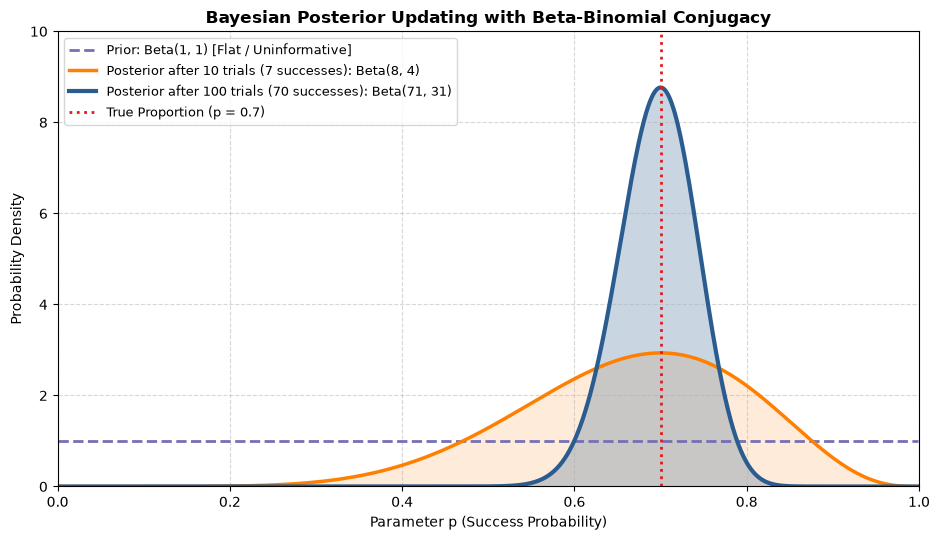

In [2]:
#| label: fig-beta-binomial-update
#| fig-cap: "Bayesian learning in action via Beta-Binomial conjugacy. Starting with a flat Beta(1, 1) prior (dashed line), observing 7 successes in 10 trials updates our belief to Beta(8, 4). As more data accumulates (e.g., 70 successes in 100 trials), the posterior Beta(71, 31) sharpens tightly around the true proportion p = 0.7."

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

p_grid = np.linspace(0.001, 0.999, 1000)

# Prior: Beta(1, 1)
prior = beta.pdf(p_grid, 1, 1)

# Posterior after n=10, k=7 -> Beta(1+7, 1+3) = Beta(8, 4)
post_10 = beta.pdf(p_grid, 8, 4)

# Posterior after n=100, k=70 -> Beta(1+70, 1+30) = Beta(71, 31)
post_100 = beta.pdf(p_grid, 71, 31)

plt.figure(figsize=(9.5, 5.5))
plt.plot(p_grid, prior, label='Prior: Beta(1, 1) [Flat / Uninformative]', color='#7570b3', linestyle='--', linewidth=2)
plt.plot(p_grid, post_10, label='Posterior after 10 trials (7 successes): Beta(8, 4)', color='#ff7f00', linewidth=2.5)
plt.fill_between(p_grid, post_10, alpha=0.15, color='#ff7f00')
plt.plot(p_grid, post_100, label='Posterior after 100 trials (70 successes): Beta(71, 31)', color='#2b5c8f', linewidth=3)
plt.fill_between(p_grid, post_100, alpha=0.25, color='#2b5c8f')

plt.axvline(x=0.7, color='#e41a1c', linestyle=':', linewidth=2, label='True Proportion (p = 0.7)')
plt.title('Bayesian Posterior Updating with Beta-Binomial Conjugacy', fontsize=12, fontweight='bold')
plt.xlabel('Parameter p (Success Probability)')
plt.ylabel('Probability Density')
plt.xlim(0, 1)
plt.ylim(0, 10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=9.5)
plt.tight_layout()
plt.show()


## 3\. Bayes' Billiards: A Story Proof of the Beta Integral

Evaluating the Beta normalization integral $\int_0^1 x^{a-1}(1-x)^{b-1} dx$ directly using standard calculus methods (integration by parts or substitution) becomes notoriously tedious when the exponents are large integers. However, when $a$ and $b$ are positive integers—say $a = k + 1$ and $b = n - k + 1$—we can evaluate the integral in a single line using a famous probabilistic argument known as **Bayes' Billiards** (or Bayes' billiard table).

::: {#thm-bayes-billiards}
## Bayes' Billiards Integral Identity
For any non-negative integers $n$ and $k$ such that $0 \le k \le n$, the definite integral of the binomial kernel over $[0, 1]$ satisfies:

$$
\int_0^1 \binom{n}{k} p^k (1 - p)^{n - k} \, dp = \frac{1}{n + 1}
$$

Consequently, the Beta normalization integral for integer parameters satisfies:

$$
\int_0^1 x^k (1 - x)^{n - k} \, dx = \frac{k!(n - k)!}{(n + 1)!} \implies B(k + 1, \, n - k + 1) = \frac{k!(n - k)!}{(n + 1)!}
$$
:::

::: {.callout-tip collapse="true"}
## Proof of the Integral Identity via Bayes' Billiards Story Proof
Consider the following thought experiment on a pool table represented by the unit interval $(0, 1)$:

**The Setup (Two Equivalent Stories):**
We have $n + 1$ billiard balls.
We roll all $n + 1$ balls onto the table such that their landing positions are independent and identically distributed [Uniform random variables](uniform-distribution.ipynb) on $(0, 1)$:

$$
U_1, U_2, \dots, U_n, U_{n+1} \stackrel{\text{i.i.d.}}{\sim} \text{Unif}(0, 1)
$$

Now, we select one specific ball to be painted **pink**, while the remaining $n$ balls remain **white**. We can execute this selection in two completely equivalent ways:

**Story 1 (Conditioning on the Pink Ball's Position $p$):**
First, we throw the pink ball onto the table. Its landing position $p \in (0, 1)$ is drawn uniformly from $\text{Unif}(0, 1)$, so its density is $f(p) = 1$ on $(0, 1)$.
Next, we throw the remaining $n$ white balls independently onto the table.
Let the random variable $X$ denote the **number of white balls that land to the left of the pink ball** (i.e., balls with position $< p$).
Given that the pink ball landed at position $p$, each individual white ball falls to the left of $p$ with independent success probability exactly equal to $p$ (since $P(U_i < p) = p$ for a uniform variable on $(0, 1)$).
Therefore, conditional on $p$, the count of white balls to the left follows a Binomial distribution:

$$
X \mid p \sim \text{Bin}(n, p) \implies P(X = k \mid p) = \binom{n}{k} p^k (1 - p)^{n - k}
$$

By the continuous [Law of Total Probability](law-of-total-probability.ipynb), to find the marginal probability $P(X = k)$ across all possible landing spots of the pink ball, we integrate over the density of $p$:

$$
\begin{aligned}
P(X = k) &= \int_0^1 P(X = k \mid p) f(p) \, dp \\
&= \int_0^1 \binom{n}{k} p^k (1 - p)^{n - k} \cdot 1 \, dp
\end{aligned}
$$

**Story 2 (Symmetry across Order Statistics):**
Instead of throwing the pink ball first, imagine we throw **all $n + 1$ identical white balls simultaneously** onto the table.
Since the $n + 1$ landing spots $U_1, \dots, U_{n+1}$ are independent and continuous, they almost surely land at distinct locations, naturally partitioning the table into a left-to-right ordering from the 1st ball (leftmost) to the $(n+1)$-th ball (rightmost).
After all $n + 1$ balls have come to rest, we uniformly at random pick **exactly 1 of the $n + 1$ balls** on the table and paint it **pink**.
Because all $n + 1$ balls are identically distributed, by strict symmetry every single ball on the table has an exactly equal probability $\frac{1}{n+1}$ of being chosen to be the pink ball!
If we happen to pick the $(k+1)$-th ball from the left to be painted pink, then exactly $k$ white balls lie to its left.
Thus, the probability that exactly $k$ white balls end up to the left of the pink ball is uniform across all possible counts $k \in \{0, 1, \dots, n\}$:

$$
P(X = k) = \frac{1}{n + 1}
$$

**Equating Both Stories:**
Because Story 1 and Story 2 describe the exact same physical event ($X = k$ white balls to the left of the pink ball), their probabilities must be identical:

$$
\int_0^1 \binom{n}{k} p^k (1 - p)^{n - k} \, dp = \frac{1}{n + 1}
$$

Dividing both sides by the binomial coefficient $\binom{n}{k} = \frac{n!}{k!(n-k)!}$ immediately yields the integral identity:

$$
\int_0^1 x^k (1 - x)^{n - k} \, dx = \frac{1}{(n + 1)\binom{n}{k}} = \frac{k!(n - k)!}{(n + 1)!}
$$

$\blacksquare$
:::

::: {.callout-note}
## Intuition: Order Statistics and Uniform Partitions
Why does picking one ball uniformly among $n+1$ uniform throws yield $\frac{1}{n+1}$?
When $n+1$ points are thrown onto $(0, 1)$, they divide the interval into $n+2$ sub-intervals (or bins). By symmetry, the $n+1$ points are completely indistinguishable in their relative ordering before one is chosen. Choosing which order statistic becomes the pink ball is mathematically equivalent to asking which of the $n+1$ ranked positions it occupies, which must be uniformly distributed across all $n+1$ possibilities.
:::

> **References & Acknowledgments:**
> Notes adapted from Stat 110: Probability (Lecture 23: Beta Distribution and Bayes' Billiards) by Joe Blitzstein ([YouTube Reference](https://www.youtube.com/watch?v=UZjlBQbV1KU&list=PL2SOU6wwxB0uwwH80KTQ6ht66KWxbzTIo&index=23)).